# RQ2: do sparse features only activate on similar images?

The SAE paper shows sparse dimensions that each have a clear meaning: one fires on
cigarettes, one on ships, and so on, and the images that activate it all share that
theme. We check whether that holds for our smaller efficientnet and mobilenet SAEs,
or whether most dimensions fire on a random mix of images.

We use the `image_to_sparse` analysis: for each dimension we have the images that
activate it (the gallery) and, for the strongest activators, a heatmap showing which
part of the image drove the activation.

First a demo to browse single dimensions, then the final illustrative figure.

In [129]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

OUTPUT = Path("output")
RUNS = {
    "efficientnet": "efficientnet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
    "mobilenet": "mobilenet_adamw_l10.0004_lr0.001_x32_e200_b4096_n100000_seed0",
}


def activators_base(model: str) -> Path:
    """The activator gallery folder for a model (the biggest one if there are several).

    The folder is named activators_<split>_n<N>; we pick the largest N so we use the
    galleries built over the most images.
    """
    base = OUTPUT / RUNS[model] / "image_to_sparse"
    folders = [d for d in base.iterdir() if d.name.startswith("activators_")]
    return max(folders, key=lambda d: int(d.name.split("_n")[-1]))


def activators_dir(model: str) -> Path:
    """The per-dimension activator galleries for a model."""
    return activators_base(model) / "dimensions"


def method_dir(model: str, method: str) -> Path:
    """An image_to_sparse method folder, for its attribution heatmaps."""
    base = OUTPUT / RUNS[model] / "image_to_sparse"
    return next(d for d in base.iterdir() if d.name.startswith(method))


for model in RUNS:
    stats = json.load(open(activators_base(model) / "stats.json"))
    print(f"{model}: galleries over {stats['n_images']} images, "
          f"{stats['n_dims_activated']} dims active, "
          f"{stats['frac_dims_single_activator']:.0%} fire on a single image")

efficientnet: galleries over 10000 images, 999 dims active, 1% fire on a single image
mobilenet: galleries over 10000 images, 999 dims active, 1% fire on a single image


## Demo: browse a dimension's activator gallery

For a dimension, show the images that activate it most and their class labels. If
the labels share a theme, the feature is interpretable; if they are a random mix,
it is not. This only uses the activation galleries (no attribution).

`INTERPRETABLE_DIMS` keeps the dimensions we found interesting while browsing, with
a short note on each. Set `MODEL` and `DIM` to look at any one. Switch `MODEL` to
do the same for the other model.

In [130]:
# dimensions we found interesting while browsing, with a note on what they fire on
INTERPRETABLE_DIMS = {
    "efficientnet": [
        (14, "kinda - round shapes"),
        (92, "clear - pointy ears"),
        (111, "semi - parallel straight lines"),
        (119, "semi - old cars, tanks, typewriters"),
        (161, "clear - products on shelves"),
        (173, "clear - screens, laptops, phones"),
        (238, "fluffy fur"),
        (337, "clear - tandem bikes (good one)"),
        (465, "black dogs"),
        (493, "striped cats, tigers"),
        (547, "pointy spikes on objects (good but a bit noisy)"),
    ],
    "mobilenet": [
        # to fill in after browsing the mobilenet galleries below
    ],
}


def show_gallery(model: str, dim: int) -> None:
    """Show a dimension's activator gallery and the labels of its top activators."""
    info = json.load(open(activators_dir(model) / str(dim) / "activators.json"))
    plt.figure(figsize=(10, 10))
    plt.imshow(mpimg.imread(activators_dir(model) / str(dim) / "activators.png"))
    plt.axis("off")
    plt.title(f"{model} dimension {dim}: {len(info)} activating images")
    plt.show()
    print("top activators (activation, label):")
    for a in info[:10]:
        print(f"  {a['activation']:.3f}  {a['label_name']}")


MODEL = "efficientnet"
print(f"curated dimensions for {MODEL}:")
for dim, note in INTERPRETABLE_DIMS[MODEL]:
    print(f"  {dim:5d}  {note}")

curated dimensions for efficientnet:
     14  kinda - round shapes
     92  clear - pointy ears
    111  semi - parallel straight lines
    119  semi - old cars, tanks, typewriters
    161  clear - products on shelves
    173  clear - screens, laptops, phones
    238  fluffy fur
    337  clear - tandem bikes (good one)
    465  black dogs
    493  striped cats, tigers
    547  pointy spikes on objects (good but a bit noisy)


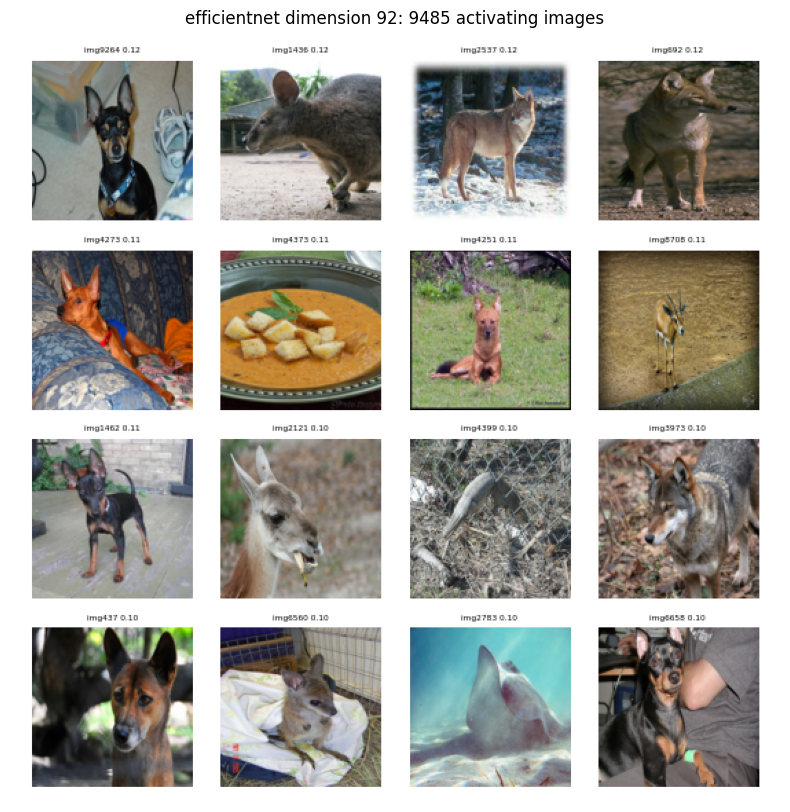

top activators (activation, label):
  0.125  miniature pinscher
  0.124  wallaby, brush kangaroo
  0.119  coyote, prairie wolf, brush wolf, Canis latrans
  0.116  coyote, prairie wolf, brush wolf, Canis latrans
  0.114  miniature pinscher
  0.113  soup bowl
  0.112  dhole, Cuon alpinus
  0.109  gazelle
  0.105  toy terrier
  0.105  llama


In [131]:
# browse one dimension (try any from the curated list, or any other dimension)
DIM = 92
show_gallery(MODEL, DIM)

## Final figure: how many dimensions are interpretable

Browsing the galleries we sort dimensions into three cases:

- **interpretable**: the activating images nearly all share a theme (a few outliers).
- **kinda-interpretable**: part of them share a theme, but about half are outliers.
- **non-interpretable**: no shared theme, a random mix.

The bar chart shows the fraction of dimensions in each case. The percentages are
placeholders for the numbers from our qualitative analysis of a sample of
dimensions. The point is that most dimensions are not cleanly interpretable.

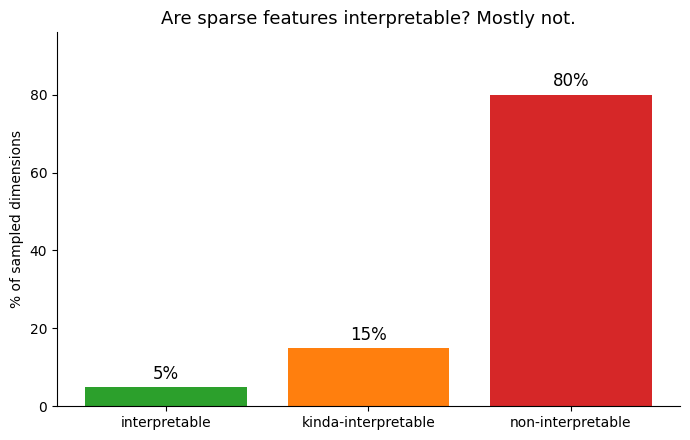

In [132]:
# PLACEHOLDERS: replace with the fractions from the qualitative analysis
CATEGORIES = {
    "interpretable": 5,
    "kinda-interpretable": 15,
    "non-interpretable": 80,
}
COLORS = ["#2ca02c", "#ff7f0e", "#d62728"]  # green, orange, red

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(list(CATEGORIES), list(CATEGORIES.values()), color=COLORS)
ax.bar_label(bars, fmt="%d%%", padding=3, fontsize=12)
ax.set_ylabel("% of sampled dimensions")
ax.set_ylim(0, max(CATEGORIES.values()) * 1.2)
ax.set_title("Are sparse features interpretable? Mostly not.", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("rq2_interpretability.png", dpi=130, bbox_inches="tight")
plt.show()

## Poster images

Dump the raw activating images (no text, no grid) for a few interesting dimensions,
so we can hand pick a couple per dimension for the poster. We only fetch the image
indices these dimensions need, in a single streaming pass that stops at the last
needed index, so it is much faster than scanning the whole split.

In [ ]:
from datasets import load_dataset

POSTER_MODEL = "efficientnet"
POSTER_DIMS = [92, 337]  # pointy ears, tandem bikes
N_SAVE = 24              # how many top activators to dump per dimension to choose from

# work out which image files are still missing (so re-running does no streaming)
wanted: dict[int, list[Path]] = {}  # image_index -> output paths still to write
for dim in POSTER_DIMS:
    folder = Path(f"rq2_{dim}_gallery")
    folder.mkdir(exist_ok=True)
    info = json.load(open(activators_dir(POSTER_MODEL) / str(dim) / "activators.json"))
    for rank, a in enumerate(info[:N_SAVE]):
        out = folder / f"{rank:02d}_act{a['activation']:.3f}_img{a['image_index']}.jpg"
        if not out.exists():
            wanted.setdefault(a["image_index"], []).append(out)

if not wanted:
    print("all poster images already saved:", [f"rq2_{dim}_gallery/" for dim in POSTER_DIMS])
else:
    # one streaming pass, stop once we are past the largest index we still need
    last = max(wanted)
    print(f"fetching {len(wanted)} images, up to index {last} ...")
    for i, ex in enumerate(load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True)):
        if i in wanted:
            image = ex["image"].convert("RGB")
            for out in wanted[i]:
                image.save(out, quality=95)
        if i >= last:
            break
    print("saved to:", [f"rq2_{dim}_gallery/" for dim in POSTER_DIMS])